player price prediction(FIFA 22)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

LOAD DATA

In [28]:
import pandas as pd

df = pd.read_csv("players_22.csv", low_memory=False)
print("Original Shape:", df.shape)


Original Shape: (19239, 110)


understand data

In [29]:
df.head() 
df.info() 
df.isnull().sum() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB


sofifa_id               0
player_url              0
short_name              0
long_name               0
player_positions        0
                    ...  
player_face_url         0
club_logo_url          61
club_flag_url          61
nation_logo_url     18480
nation_flag_url         0
Length: 110, dtype: int64

visualization before cleaning

Age توزيع الاعمار 

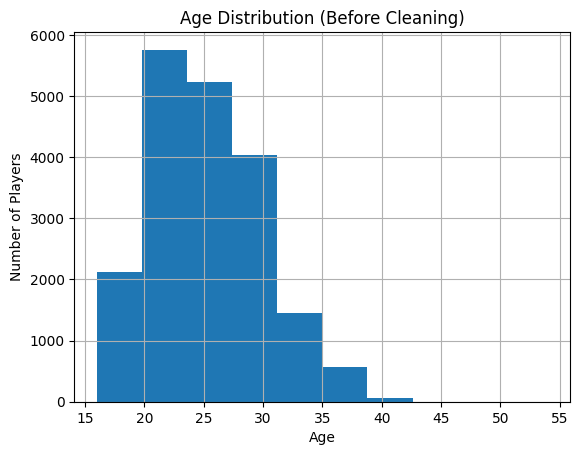

In [30]:
import matplotlib.pyplot as plt
plt.figure()
df['age'].hist()
plt.title('Age Distribution (Before Cleaning)')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

overall توزيع  التقييم العام

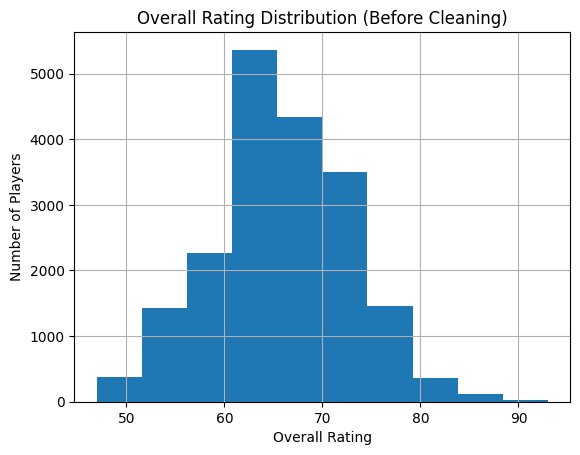

In [31]:
plt.figure()
df['overall'].hist()
plt.title('Overall Rating Distribution (Before Cleaning)')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')
plt.show()

value  توزيع القيم

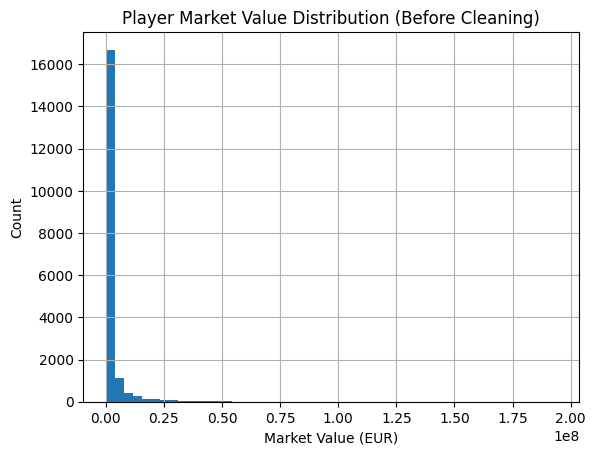

In [32]:
plt.figure()
df['value_eur'].hist(bins=50)
plt.title('Player Market Value Distribution (Before Cleaning)')
plt.xlabel('Market Value (EUR)')
plt.ylabel('Count')
plt.show()

مقارنة العمر مع السعر 

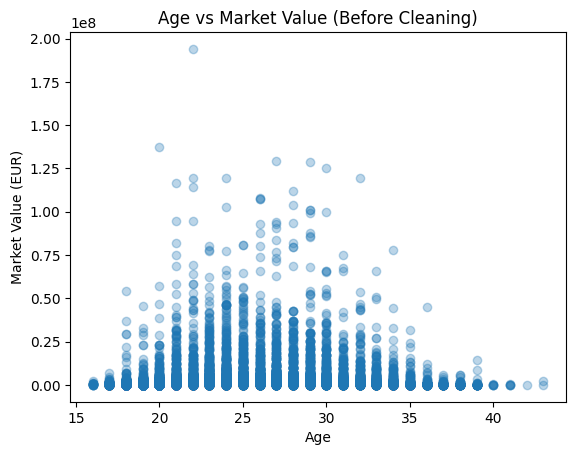

In [33]:
plt.figure()
plt.scatter(df['age'], df['value_eur'], alpha=0.3)
plt.title('Age vs Market Value (Before Cleaning)')
plt.xlabel('Age')
plt.ylabel('Market Value (EUR)')
plt.show()

لاكتشاف القيم الشاذه boxplot

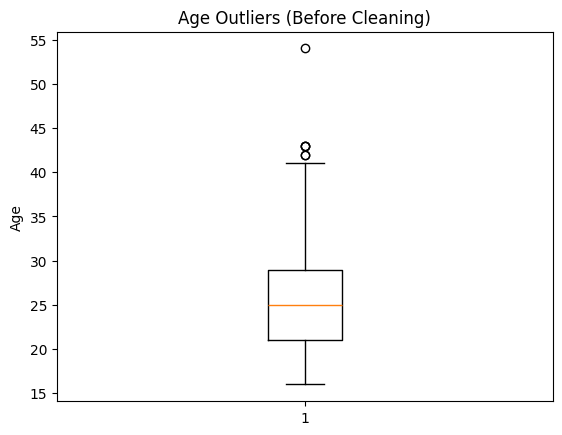

In [34]:
plt.figure()
plt.boxplot(df['age'].dropna())
plt.title('Age Outliers (Before Cleaning)')
plt.ylabel('Age')
plt.show()

ازالة الاعمده الغير مهمه

In [35]:
cols_to_drop = [
    'player_url', 'player_face_url',
    'nation_flag_url', 'club_logo_url',
    'club_flag_url', 'sofifa_id'
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

معالجه القيم الناقصة missing values

In [36]:

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

تحويل اعمده نصوص زي £ لارقام

In [37]:
def convert_money(value):
    if isinstance(value, str):
        value = value.replace('€', '')
        if 'M' in value:
            return float(value.replace('M', '')) * 1_000_000
        elif 'K' in value:
            return float(value.replace('K', '')) * 1_000
    return value
for col in ['value_eur', 'wage_eur', 'release_clause_eur']:
    if col in df.columns:
        df[col] = df[col].apply(convert_money)


ازالة صفوف متكررة

In [38]:
df.drop_duplicates(inplace=True)

ازالة القيم الشاذخ outliers

In [39]:
df = df[(df['age'] >= 16) & (df['age'] <= 45)]

التاكد من نتيجة التنظيف

In [40]:
print("Shape After Cleaning:", df.shape)
df.head()

Shape After Cleaning: (19238, 104)


,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,nation_logo_url
0,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,1987-06-24,170,...,64+3,64+3,66+3,61+3,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/teams/1369/60.png
1,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,1988-08-21,185,...,66+3,66+3,64+3,61+3,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/teams/1353/60.png
2,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,1985-02-05,187,...,59+3,59+3,63+3,60+3,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/teams/1354/60.png
3,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,1992-02-05,175,...,63+3,63+3,67+3,62+3,50+3,50+3,50+3,62+3,20+3,NaN
4,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,1991-06-28,181,...,80+3,80+3,79+3,75+3,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/teams/1325/60.png


visualization after cleaning

age after cleaning

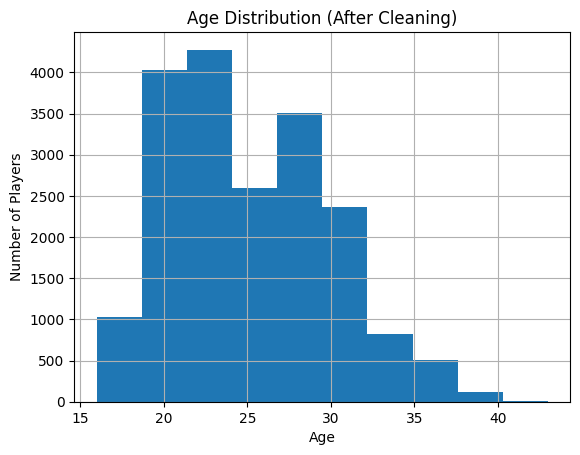

In [41]:

plt.figure()
df['age'].hist()
plt.title('Age Distribution (After Cleaning)')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.show()

overall after cleaning

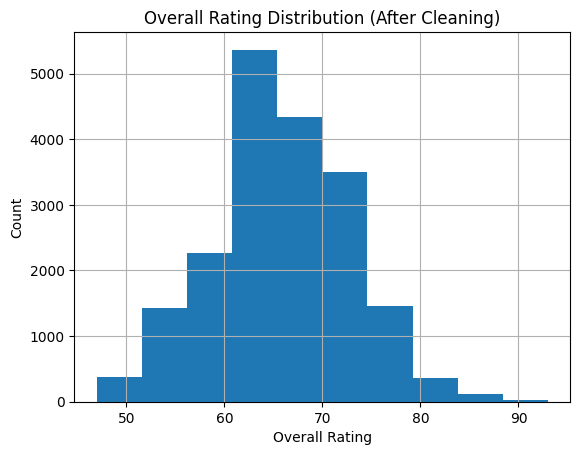

In [42]:
plt.figure()
df['overall'].hist()
plt.title('Overall Rating Distribution (After Cleaning)')
plt.xlabel('Overall Rating')
plt.ylabel('Count')
plt.show()

value market after cleaning

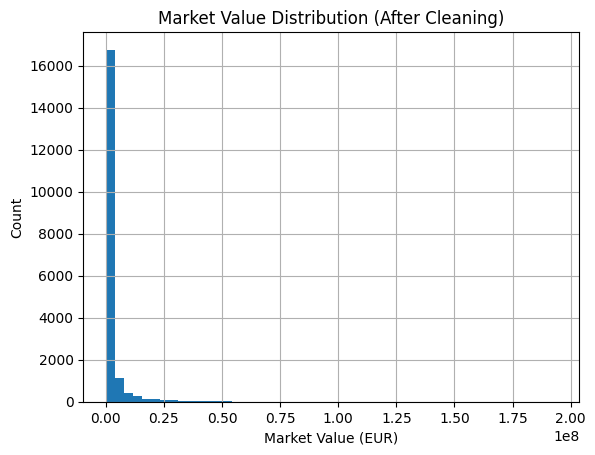

In [43]:
plt.figure()
df['value_eur'].hist(bins=50)
plt.title('Market Value Distribution (After Cleaning)')
plt.xlabel('Market Value (EUR)')
plt.ylabel('Count')
plt.show()

العمر مقابل السعر بعد التنظيف 

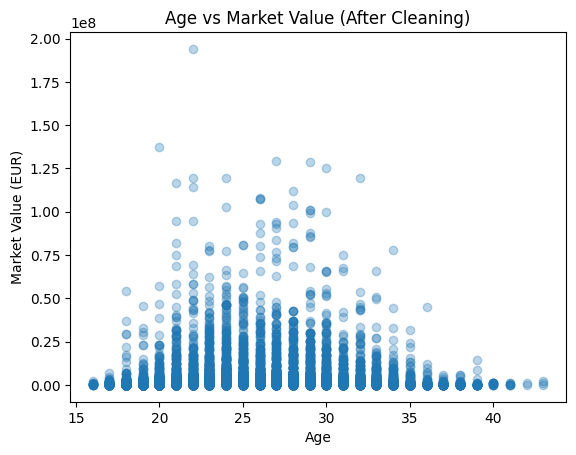

In [44]:
plt.figure()
plt.scatter(df['age'], df['value_eur'], alpha=0.3)
plt.title('Age vs Market Value (After Cleaning)')
plt.xlabel('Age')
plt.ylabel('Market Value (EUR)')
plt.show()

boxplot للاعمار بعد التنظيف 

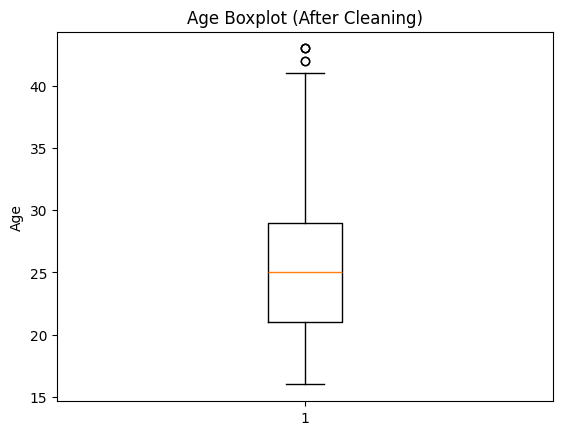

In [45]:
plt.figure()
plt.boxplot(df['age'])
plt.title('Age Boxplot (After Cleaning)')
plt.ylabel('Age')
plt.show()

feature selection       اختيار الخصائص اللي هتدخل للموديل

In [46]:
features = [
    'age', 'potential',
    'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic'
]

X = df[features]


log transform=>يقلل تاثير القيم الكبيرة الساذه على الموديل

In [47]:
import numpy as np
# Log-transform target
y = np.log1p(df['value_eur'])

train test split=> train 70% .test =30% بنختبر الموديل على داتا مش شايفها

In [48]:
from sklearn.model_selection import train_test_split
y = df['value_eur']

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model training =>random forest regression

In [49]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=8,
    min_samples_split=30,
    min_samples_leaf=12,
    max_features=0.6,
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [50]:
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),  #
    activation='tanh',
    solver='lbfgs',
    max_iter=2000,
    early_stopping=True,
     learning_rate_init=0.001,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


model evaluation

In [51]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nFinal Model Performance")
print("R2 Score:", round(r2, 3))     
print("MAE (EUR):", round(mae, 2))



comparison = pd.DataFrame({
    'Actual Value (€)': y_test.values[:10],
    'Predicted Value (€)': y_pred[:10]
})

print("\nFirst 10 Players Comparison:")
print(comparison)


Final Model Performance
R2 Score: 0.867
MAE (EUR): 692356.31

First 10 Players Comparison:
   Actual Value (€)  Predicted Value (€)
0        15000000.0         1.273833e+07
1           90000.0         5.711341e+05
2         1500000.0         1.118733e+06
3         4700000.0         2.079898e+06
4          200000.0         6.363659e+05
5         2700000.0         1.979603e+06
6          625000.0         5.085843e+05
7         3100000.0         4.145827e+06
8         8000000.0         2.050808e+07
9         6000000.0         6.740259e+06


save model=>حفظ الموديل عشان لما استخدمه بعدين في توقعات

In [52]:
import joblib
joblib.dump(rf, "player_price_predictor.pkl")
print("\nModel saved as player_price_predictor.pkl")


Model saved as player_price_predictor.pkl
